# Анализ взаимосвязей и тестирование гипотез: практический notebook от А до Я

Этот notebook показывает полный базовый путь анализа взаимосвязей и проверки гипотез на табличных данных. Материал не привязан к конкретному датасету: внутри создаётся синтетическая таблица, похожая на данные о клиентах, заказах и маркетинговых каналах.

Главная цель — понять не только команды Python, но и логику аналитической работы: как перейти от вопроса к данным, от данных к расчётам, от расчётов к интерпретации, а затем к аккуратному выводу без необоснованных причинно-следственных утверждений.

В notebook используются:

- `pandas` — для работы с таблицами;
- `matplotlib` — для графиков;
- `numpy` — только для создания примера данных и отдельных расчётов;
- `scipy.stats` — для статистических тестов.

`scikit-learn` здесь не используется, потому что задача связана не с машинным обучением, а с анализом взаимосвязей и проверкой статистических гипотез.

## 1. Что такое анализ взаимосвязей

Анализ взаимосвязей отвечает на вопрос: **как один показатель связан с другим показателем**.

Примеры вопросов:

- связаны ли количество посещений сайта и число заказов;
- отличается ли средний чек у клиентов из разных каналов привлечения;
- зависит ли факт покупки от размера скидки;
- различается ли удовлетворённость клиентов в разных городских сегментах.

Важно: взаимосвязь не равна причинности. Если два показателя связаны, это ещё не доказывает, что один показатель является причиной другого. Например, если клиенты с большим числом визитов чаще покупают, это может означать разный уровень интереса, разную рекламную активность, разные сегменты клиентов или влияние третьего фактора.

## 2. Что такое тестирование гипотез

Тестирование гипотез — это формальная проверка аналитического предположения на данных.

Обычно формулируются две гипотезы:

- **H0, нулевая гипотеза**: различий или связи нет;
- **H1, альтернативная гипотеза**: различие или связь есть.

Пример:

- H0: средний чек клиентов из органического и рекламного каналов не различается;
- H1: средний чек клиентов из органического и рекламного каналов различается.

После расчёта статистического теста обычно анализируют `p-value`. Если `p-value` меньше выбранного уровня значимости, например `0.05`, нулевая гипотеза отклоняется. Но это не означает автоматического доказательства бизнес-причины. Это означает, что наблюдаемое различие маловероятно получить случайно при условии, что нулевая гипотеза верна.

## 3. Рабочий пайплайн

Полный порядок работы будет таким:

1. Определить аналитическую цель.
2. Подготовить или загрузить данные.
3. Описать поля таблицы.
4. Проверить качество данных.
5. Определить типы переменных.
6. Выбрать методы анализа взаимосвязей.
7. Построить первичные визуализации.
8. Рассчитать метрики связи.
9. Сформулировать гипотезы.
10. Выбрать статистические тесты.
11. Выполнить тесты.
12. Оценить не только `p-value`, но и размер эффекта.
13. Сформулировать выводы.
14. Указать ограничения.
15. Собрать итоговый аналитический дашборд.

## 4. Импорт библиотек

Сначала импортируем библиотеки. Код должен запускаться сверху вниз без ручных исправлений.

In [1]:
import pandas as pd  # Импортируем pandas для работы с таблицами и датафреймами.
import matplotlib.pyplot as plt  # Импортируем matplotlib для построения базовых графиков.
import numpy as np  # Импортируем numpy для генерации синтетических данных и математических операций.
from scipy import stats  # Импортируем scipy.stats для статистических тестов и проверки гипотез.

pd.set_option('display.max_columns', None)  # Разрешаем pandas показывать все столбцы таблицы без скрытия.
pd.set_option('display.width', 120)  # Настраиваем ширину вывода, чтобы таблицы удобнее читались в notebook.

rng = np.random.default_rng(42)  # Фиксируем генератор случайных чисел, чтобы пример воспроизводился при каждом запуске.


## 5. Создание демонстрационного датасета

Чтобы notebook был полностью самостоятельным, создадим синтетический датасет. Он будет имитировать данные о клиентах, каналах привлечения, скидках, посещениях сайта, заказах, среднем чеке и удовлетворённости.

В реальной задаче вместо этого блока обычно используется загрузка CSV, Excel, SQL-выгрузки или данных из API.

In [2]:
n = 900  # Задаём количество наблюдений, то есть число условных клиентов в синтетическом датасете.

customer_id = np.arange(1, n + 1)  # Создаём уникальные идентификаторы клиентов от 1 до n.

age_group = rng.choice(  # Генерируем возрастную группу для каждого клиента.
    ['18-25', '26-35', '36-45', '46-60'],  # Задаём возможные возрастные группы.
    size=n,  # Указываем, что нужно получить n значений.
    p=[0.22, 0.38, 0.25, 0.15]  # Задаём вероятности появления каждой возрастной группы.
)  # Завершаем генерацию массива возрастных групп.

city_segment = rng.choice(  # Генерируем тип городской территории для каждого клиента.
    ['центр', 'спальные районы', 'пригород'],  # Задаём возможные сегменты города.
    size=n,  # Указываем количество генерируемых значений.
    p=[0.28, 0.52, 0.20]  # Задаём вероятности для центра, спальных районов и пригорода.
)  # Завершаем генерацию массива городских сегментов.

traffic_source = rng.choice(  # Генерируем канал привлечения клиента.
    ['organic', 'ads', 'social', 'referral'],  # Задаём возможные источники трафика.
    size=n,  # Указываем число клиентов, для которых нужен источник трафика.
    p=[0.36, 0.30, 0.22, 0.12]  # Задаём вероятности появления каждого канала.
)  # Завершаем генерацию массива источников трафика.

discount_group = rng.choice(  # Генерируем группу скидки для каждого клиента.
    ['no_discount', 'small_discount', 'large_discount'],  # Задаём возможные уровни скидки.
    size=n,  # Указываем количество клиентов.
    p=[0.42, 0.38, 0.20]  # Задаём вероятности для каждой группы скидки.
)  # Завершаем генерацию массива скидочных групп.

source_visit_effect = {  # Создаём словарь, где каждому каналу трафика соответствует среднее число посещений.
    'organic': 5,  # Для органического трафика задаём средний уровень посещений.
    'ads': 7,  # Для рекламного трафика задаём более высокий уровень посещений.
    'social': 6,  # Для социальных сетей задаём промежуточный уровень посещений.
    'referral': 4  # Для реферального трафика задаём более низкий уровень посещений.
}  # Завершаем описание эффекта источника трафика на посещения.
monthly_visits = np.array([  # Создаём массив количества посещений за месяц.
    rng.poisson(source_visit_effect[src]) for src in traffic_source  # Для каждого клиента генерируем посещения с учётом его канала.
]) + 1  # Добавляем 1, чтобы не получать нулевые посещения в демонстрационном примере.

source_basket_effect = {  # Создаём словарь базового среднего чека по источникам трафика.
    'organic': 5200,  # Для органического трафика задаём базовый средний чек.
    'ads': 4700,  # Для рекламного трафика задаём базовый средний чек.
    'social': 4300,  # Для трафика из социальных сетей задаём базовый средний чек.
    'referral': 5600  # Для реферального трафика задаём базовый средний чек.
}  # Завершаем описание влияния источника трафика на средний чек.

discount_basket_effect = {  # Создаём словарь влияния скидочной группы на средний чек.
    'no_discount': 800,  # Без скидки средний чек условно выше.
    'small_discount': 200,  # При небольшой скидке средний чек немного выше базового уровня.
    'large_discount': -300  # При большой скидке средний чек ниже из-за скидочного эффекта.
}  # Завершаем описание влияния скидки на средний чек.

basket_value = np.array([  # Создаём массив среднего чека для каждого клиента.
    source_basket_effect[src] + discount_basket_effect[disc] + rng.normal(0, 900)  # Складываем эффект канала, скидки и случайный шум.
    for src, disc in zip(traffic_source, discount_group)  # Проходим одновременно по источнику трафика и группе скидки.
])  # Завершаем генерацию среднего чека.

basket_value = np.clip(basket_value, 1200, None).round(0)  # Ограничиваем минимальный чек и округляем значение до целых.

discount_conversion_effect = {  # Создаём словарь влияния скидки на вероятность покупки.
    'no_discount': -0.35,  # Без скидки вероятность покупки условно ниже.
    'small_discount': 0.15,  # Небольшая скидка повышает вероятность покупки.
    'large_discount': 0.55  # Большая скидка сильнее повышает вероятность покупки.
}  # Завершаем описание влияния скидки на конверсию.

logit = -1.6 + 0.18 * monthly_visits + np.array([discount_conversion_effect[d] for d in discount_group])  # Рассчитываем логит как основу вероятности покупки.
conversion_probability = 1 / (1 + np.exp(-logit))  # Преобразуем логит в вероятность от 0 до 1 через логистическую функцию.
converted = rng.binomial(1, conversion_probability)  # Генерируем факт покупки: 1 означает покупку, 0 означает отсутствие покупки.

orders_count = np.where(  # Генерируем количество заказов с разной логикой для купивших и не купивших клиентов.
    converted == 1,  # Проверяем условие: клиент совершил покупку.
    rng.poisson(1 + monthly_visits / 4),  # Для купивших клиентов число заказов зависит от посещений.
    rng.poisson(0.25, size=n)  # Для не купивших клиентов оставляем малое случайное значение заказов.
)  # Завершаем расчёт количества заказов.

satisfaction_score = (  # Рассчитываем оценку удовлетворённости клиента.
    3.5  # Берём базовый уровень удовлетворённости.
    + 0.18 * orders_count  # Увеличиваем оценку при большем числе заказов.
    - np.where(discount_group == 'large_discount', 0.15, 0)  # Немного снижаем оценку для большой скидки как демонстрационное допущение.
    + rng.normal(0, 0.65, size=n)  # Добавляем случайный шум, чтобы данные не были искусственно идеальными.
)  # Завершаем расчёт исходной удовлетворённости.
satisfaction_score = np.clip(satisfaction_score, 1, 5).round(1)  # Ограничиваем оценку диапазоном от 1 до 5 и округляем до одного знака.

basket_value_with_missing = basket_value.astype('float')  # Переводим средний чек в float, чтобы можно было записать NaN.
missing_idx = rng.choice(n, size=18, replace=False)  # Случайно выбираем индексы строк, где будут пропуски.
basket_value_with_missing[missing_idx] = np.nan  # В выбранные строки записываем пропуски в среднем чеке.

df = pd.DataFrame({  # Собираем все сгенерированные массивы в одну таблицу pandas.
    'customer_id': customer_id,  # Добавляем идентификатор клиента.
    'age_group': age_group,  # Добавляем возрастную группу.
    'city_segment': city_segment,  # Добавляем городской сегмент.
    'traffic_source': traffic_source,  # Добавляем канал привлечения.
    'discount_group': discount_group,  # Добавляем группу скидки.
    'monthly_visits': monthly_visits,  # Добавляем количество посещений за месяц.
    'basket_value': basket_value_with_missing,  # Добавляем средний чек с искусственно созданными пропусками.
    'orders_count': orders_count,  # Добавляем количество заказов.
    'converted': converted,  # Добавляем факт покупки.
    'satisfaction_score': satisfaction_score  # Добавляем оценку удовлетворённости.
})  # Завершаем создание датафрейма.

df = pd.concat([df, df.sample(5, random_state=42)], ignore_index=True)  # Добавляем 5 дубликатов строк для демонстрации проверки качества данных.

df.head()  # Показываем первые строки таблицы для первичного визуального контроля.


,customer_id,age_group,city_segment,traffic_source,discount_group,monthly_visits,basket_value,orders_count,converted,satisfaction_score
0,1,36-45,спальные районы,ads,small_discount,6,5547.0,0,0,3.1
1,2,26-35,центр,ads,small_discount,6,5138.0,4,1,4.2
2,3,46-60,центр,organic,no_discount,7,5376.0,0,0,4.2
3,4,36-45,спальные районы,social,large_discount,11,4347.0,2,1,4.7
4,5,18-25,пригород,social,small_discount,6,4440.0,1,1,3.8


## 6. Описание полей таблицы

Перед расчётами нужно понять смысл каждого столбца. Без этого можно выбрать неправильный метод анализа или сделать некорректный вывод.

Описание полей:

| Поле | Смысл | Тип переменной |
|---|---|---|
| `customer_id` | идентификатор клиента | техническое поле |
| `age_group` | возрастная группа клиента | категориальная |
| `city_segment` | тип территории проживания | категориальная |
| `traffic_source` | канал привлечения | категориальная |
| `discount_group` | уровень скидки | категориальная порядковая |
| `monthly_visits` | число посещений за месяц | числовая дискретная |
| `basket_value` | средний чек клиента | числовая непрерывная |
| `orders_count` | число заказов | числовая дискретная |
| `converted` | факт покупки: 1 — купил, 0 — не купил | бинарная |
| `satisfaction_score` | оценка удовлетворённости от 1 до 5 | числовая / порядковая |

В реальном анализе такой словарь данных желательно составлять сразу после загрузки таблицы.

## 7. Первичный осмотр данных

На этом шаге нужно понять размер таблицы, типы данных, примеры строк и базовые статистики. Это помогает быстро обнаружить ошибки загрузки, странные типы, пропуски и потенциально проблемные поля.

In [3]:
print('Размер таблицы:', df.shape)  # Выводим число строк и столбцов в исходной таблице.
print('\nТипы данных:')  # Печатаем заголовок блока с типами данных.
display(df.dtypes)  # Показываем тип данных каждого столбца.

print('\nПервые строки:')  # Печатаем заголовок блока с первыми строками таблицы.
display(df.head())  # Показываем первые пять строк датафрейма.

print('\nОписательная статистика по числовым полям:')  # Печатаем заголовок блока описательной статистики.
display(df.describe())  # Показываем базовые статистики: среднее, стандартное отклонение, минимум, максимум и квартили.


Размер таблицы: (905, 10)

Типы данных:


customer_id             int32
age_group              object
city_segment           object
traffic_source         object
discount_group         object
monthly_visits          int32
basket_value          float64
orders_count            int64
converted               int64
satisfaction_score    float64
dtype: object


Первые строки:


,customer_id,age_group,city_segment,traffic_source,discount_group,monthly_visits,basket_value,orders_count,converted,satisfaction_score
0,1,36-45,спальные районы,ads,small_discount,6,5547.0,0,0,3.1
1,2,26-35,центр,ads,small_discount,6,5138.0,4,1,4.2
2,3,46-60,центр,organic,no_discount,7,5376.0,0,0,4.2
3,4,36-45,спальные районы,social,large_discount,11,4347.0,2,1,4.7
4,5,18-25,пригород,social,small_discount,6,4440.0,1,1,3.8



Описательная статистика по числовым полям:


,customer_id,monthly_visits,basket_value,orders_count,converted,satisfaction_score
count,905.000000,905.000000,887.000000,905.000000,905.000000,905.000000
mean,449.955801,6.667403,5228.052988,1.398895,0.426519,3.705967
std,260.342733,2.689888,1099.358928,1.864610,0.494845,0.706377
min,1.000000,1.000000,2217.000000,0.000000,0.000000,1.700000
25%,225.000000,5.000000,4466.000000,0.000000,0.000000,3.200000
50%,450.000000,6.000000,5214.000000,1.000000,0.000000,3.700000
75%,675.000000,8.000000,5984.000000,2.000000,1.000000,4.200000
max,900.000000,20.000000,8758.000000,10.000000,1.000000,5.000000


## 8. Проверка качества данных

Перед анализом взаимосвязей нужно проверить минимум четыре вещи:

1. пропуски;
2. дубликаты;
3. некорректные значения;
4. выбросы.

Если пропустить этот этап, можно получить красивый график и формально значимый тест, но результат будет недостоверным.

In [4]:
quality_report = pd.DataFrame({  # Создаём таблицу с отчётом о качестве данных.
    'dtype': df.dtypes,  # Добавляем тип данных для каждого столбца.
    'missing_count': df.isna().sum(),  # Считаем количество пропусков в каждом столбце.
    'missing_share': (df.isna().mean() * 100).round(2),  # Считаем долю пропусков в процентах и округляем до двух знаков.
    'unique_count': df.nunique()  # Считаем количество уникальных значений в каждом столбце.
})  # Завершаем создание отчёта о качестве данных.

display(quality_report)  # Показываем отчёт о типах, пропусках и уникальных значениях.

print('Количество полных дубликатов:', df.duplicated().sum())  # Выводим число полностью совпадающих строк.


,dtype,missing_count,missing_share,unique_count
customer_id,int32,0,0.00,900
age_group,object,0,0.00,4
city_segment,object,0,0.00,3
traffic_source,object,0,0.00,4
discount_group,object,0,0.00,3
monthly_visits,int32,0,0.00,18
basket_value,float64,18,1.99,793
orders_count,int64,0,0.00,11
converted,int64,0,0.00,2
satisfaction_score,float64,0,0.00,34


Количество полных дубликатов: 5


## 9. Подготовка данных

В демонстрационном датасете есть пропуски в `basket_value` и несколько дубликатов. Для простого анализа:

- удалим дубликаты;
- пропуски в `basket_value` заполним медианой по каналу привлечения, потому что средний чек может различаться между каналами;
- проверим, что ключевые поля не содержат невозможных значений.

В реальной работе способ обработки пропусков нужно объяснять. Нельзя автоматически заполнять данные без обоснования.

In [5]:
df_clean = df.drop_duplicates().copy()  # Удаляем полные дубликаты и создаём независимую копию очищаемой таблицы.

df_clean['basket_value'] = df_clean.groupby('traffic_source')['basket_value'].transform(  # Заполняем пропуски в среднем чеке внутри групп по каналу привлечения.
    lambda x: x.fillna(x.median())  # Для каждой группы заменяем пропуски медианой этой же группы.
)  # Завершаем заполнение пропусков в столбце basket_value.

checks = {  # Создаём словарь контрольных проверок на некорректные значения.
    'monthly_visits_negative': (df_clean['monthly_visits'] < 0).sum(),  # Проверяем, есть ли отрицательные посещения.
    'basket_value_non_positive': (df_clean['basket_value'] <= 0).sum(),  # Проверяем, есть ли нулевой или отрицательный средний чек.
    'orders_count_negative': (df_clean['orders_count'] < 0).sum(),  # Проверяем, есть ли отрицательное число заказов.
    'converted_not_0_or_1': (~df_clean['converted'].isin([0, 1])).sum(),  # Проверяем, есть ли значения конверсии кроме 0 и 1.
    'satisfaction_out_of_range': (~df_clean['satisfaction_score'].between(1, 5)).sum()  # Проверяем, есть ли оценки удовлетворённости вне диапазона 1-5.
}  # Завершаем словарь контрольных проверок.

print('Проверки некорректных значений:')  # Выводим заголовок блока проверок.
for key, value in checks.items():  # Перебираем все проверки из словаря.
    print(f'{key}: {value}')  # Печатаем название проверки и число найденных проблем.

print('\nРазмер после очистки:', df_clean.shape)  # Показываем размер таблицы после удаления дубликатов и заполнения пропусков.
print('Осталось пропусков:', df_clean.isna().sum().sum())  # Показываем общее количество оставшихся пропусков во всей таблице.


Проверки некорректных значений:
monthly_visits_negative: 0
basket_value_non_positive: 0
orders_count_negative: 0
converted_not_0_or_1: 0
satisfaction_out_of_range: 0

Размер после очистки: (900, 10)
Осталось пропусков: 0


## 10. Как выбирать метод анализа взаимосвязи

Метод зависит от типов переменных.

| Тип связи | Пример | Что использовать |
|---|---|---|
| числовая ↔ числовая | посещения и заказы | scatter plot, Pearson, Spearman |
| категориальная ↔ числовая | канал и средний чек | группировка, boxplot, t-test, ANOVA, Mann-Whitney, Kruskal-Wallis |
| категориальная ↔ категориальная | скидка и факт покупки | таблица сопряжённости, доли, chi-square, Cramer's V |
| бинарная ↔ числовая | покупка и средний чек | сравнение двух групп, t-test или Mann-Whitney |

Важно: статистический тест выбирается не по желанию аналитика, а по структуре данных и вопросу анализа.

## 11. Взаимосвязь числовых переменных

Начнём с вопроса: связаны ли число посещений сайта и число заказов?

Аналитическая логика:

- если клиент чаще посещает сайт, он может чаще делать заказы;
- но связь может быть нелинейной или зависеть от других факторов;
- сначала строим график, затем считаем коэффициенты связи.

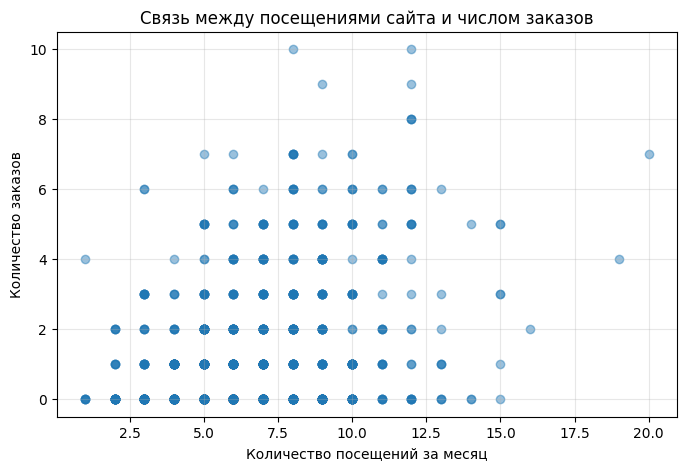

Корреляция Pearson: 0.352
Корреляция Spearman: 0.331


In [6]:
plt.figure(figsize=(8, 5))  # Создаём область графика размером 8 на 5 дюймов.
plt.scatter(df_clean['monthly_visits'], df_clean['orders_count'], alpha=0.45)  # Строим диаграмму рассеяния посещений и заказов.
plt.title('Связь между посещениями сайта и числом заказов')  # Добавляем заголовок графика.
plt.xlabel('Количество посещений за месяц')  # Подписываем ось X.
plt.ylabel('Количество заказов')  # Подписываем ось Y.
plt.grid(True, alpha=0.3)  # Добавляем сетку для удобства чтения графика.
plt.show()  # Отображаем график.

pearson_corr = df_clean['monthly_visits'].corr(df_clean['orders_count'], method='pearson')  # Считаем линейную корреляцию Pearson.
spearman_corr = df_clean['monthly_visits'].corr(df_clean['orders_count'], method='spearman')  # Считаем ранговую корреляцию Spearman.

print(f'Корреляция Pearson: {pearson_corr:.3f}')  # Выводим значение корреляции Pearson с округлением.
print(f'Корреляция Spearman: {spearman_corr:.3f}')  # Выводим значение корреляции Spearman с округлением.


### Как интерпретировать корреляцию

Корреляция находится в диапазоне от `-1` до `1`.

- значение около `1` означает сильную прямую связь;
- значение около `-1` означает сильную обратную связь;
- значение около `0` означает отсутствие выраженной линейной связи.

Pearson лучше подходит для линейной связи числовых переменных. Spearman оценивает монотонную связь и более устойчив к выбросам и нелинейности.

Даже высокая корреляция не доказывает причинность. Она показывает совместное изменение показателей, но не объясняет механизм.

## 12. Корреляционная матрица

Корреляционная матрица помогает быстро увидеть связи между несколькими числовыми показателями. Она полезна как обзорный инструмент, но не заменяет содержательную интерпретацию.

,monthly_visits,basket_value,orders_count,converted,satisfaction_score
monthly_visits,1.000,-0.149,0.331,0.258,0.171
basket_value,-0.149,1.000,-0.105,-0.092,0.013
orders_count,0.331,-0.105,1.000,0.787,0.411
converted,0.258,-0.092,0.787,1.000,0.332
satisfaction_score,0.171,0.013,0.411,0.332,1.000


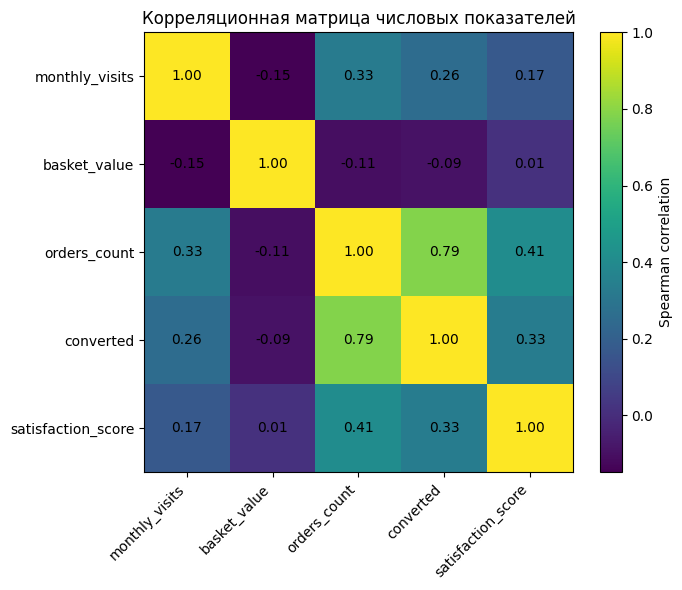

In [7]:
numeric_cols = ['monthly_visits', 'basket_value', 'orders_count', 'converted', 'satisfaction_score']  # Задаём список числовых столбцов для корреляционного анализа.
corr_matrix = df_clean[numeric_cols].corr(method='spearman')  # Считаем корреляционную матрицу методом Spearman.

display(corr_matrix.round(3))  # Показываем корреляционную матрицу с округлением до трёх знаков.

plt.figure(figsize=(7, 6))  # Создаём область графика для тепловой карты.
plt.imshow(corr_matrix, aspect='auto')  # Показываем матрицу как изображение с цветовым кодированием значений.
plt.colorbar(label='Spearman correlation')  # Добавляем цветовую шкалу с подписью.
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha='right')  # Подписываем столбцы матрицы на оси X.
plt.yticks(range(len(numeric_cols)), numeric_cols)  # Подписываем строки матрицы на оси Y.
plt.title('Корреляционная матрица числовых показателей')  # Добавляем заголовок тепловой карты.

for i in range(len(numeric_cols)):  # Перебираем строки корреляционной матрицы.
    for j in range(len(numeric_cols)):  # Перебираем столбцы корреляционной матрицы.
        plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center')  # Подписываем значение корреляции внутри каждой ячейки.

plt.tight_layout()  # Автоматически выравниваем элементы графика, чтобы подписи не обрезались.
plt.show()  # Отображаем тепловую карту.


## 13. Взаимосвязь категориальной и числовой переменной

Теперь проверим, отличается ли средний чек в разных каналах привлечения.

Здесь `traffic_source` — категориальная переменная, а `basket_value` — числовая. Сначала считаем групповые показатели, затем строим визуализацию.

In [8]:
basket_by_source = (  # Начинаем расчёт агрегированной таблицы среднего чека по каналам привлечения.
    df_clean  # Берём очищенный датафрейм.
    .groupby('traffic_source')  # Группируем клиентов по каналу привлечения.
    .agg(  # Рассчитываем несколько показателей внутри каждой группы.
        clients=('customer_id', 'count'),  # Считаем количество клиентов в группе.
        mean_basket=('basket_value', 'mean'),  # Считаем средний средний чек в группе.
        median_basket=('basket_value', 'median'),  # Считаем медианный средний чек в группе.
        std_basket=('basket_value', 'std')  # Считаем стандартное отклонение среднего чека в группе.
    )  # Завершаем расчёт агрегированных показателей.
    .sort_values('median_basket', ascending=False)  # Сортируем каналы по медианному среднему чеку от большего к меньшему.
)  # Завершаем создание агрегированной таблицы.

basket_by_source.round(2)  # Показываем таблицу с округлением числовых значений до двух знаков.


,clients,mean_basket,median_basket,std_basket
traffic_source,,,,
referral,109,5909.55,5962.0,1005.34
organic,318,5556.28,5515.5,1017.15
ads,289,5024.10,5007.0,953.11
social,184,4572.47,4521.0,1016.54


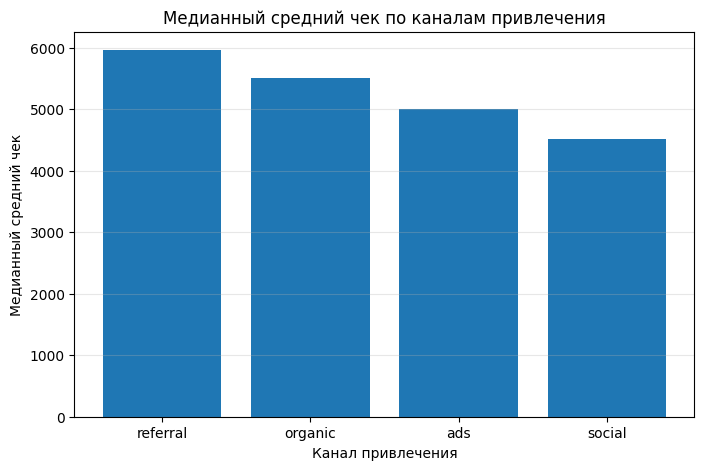

In [9]:
plt.figure(figsize=(8, 5))  # Создаём область графика размером 8 на 5 дюймов.
plt.bar(basket_by_source.index, basket_by_source['median_basket'])  # Строим столбчатую диаграмму медианного среднего чека по каналам.
plt.title('Медианный средний чек по каналам привлечения')  # Добавляем заголовок графика.
plt.xlabel('Канал привлечения')  # Подписываем ось X.
plt.ylabel('Медианный средний чек')  # Подписываем ось Y.
plt.grid(axis='y', alpha=0.3)  # Добавляем горизонтальную сетку для удобства сравнения столбцов.
plt.show()  # Отображаем график.


### Boxplot для сравнения распределений

Столбчатый график показывает только одно агрегированное значение. Boxplot полезнее, когда нужно сравнить распределения: медиану, разброс и потенциальные выбросы.

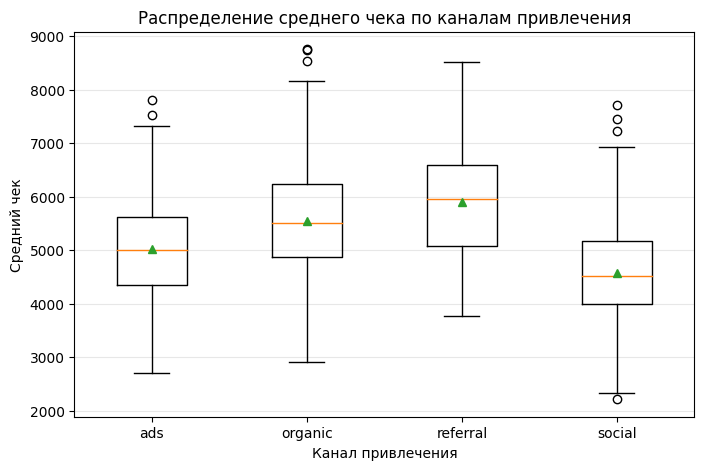

In [10]:
groups = [  # Создаём список массивов среднего чека для boxplot.
    df_clean.loc[df_clean['traffic_source'] == src, 'basket_value']  # Берём средний чек только для одного канала привлечения.
    for src in sorted(df_clean['traffic_source'].unique())  # Повторяем операцию для каждого уникального канала.
]  # Завершаем формирование списка групп.
labels = sorted(df_clean['traffic_source'].unique())  # Создаём подписи групп в том же порядке, что и данные.

plt.figure(figsize=(8, 5))  # Создаём область графика размером 8 на 5 дюймов.
plt.boxplot(groups, labels=labels, showmeans=True)  # Строим boxplot для сравнения распределений среднего чека по каналам.
plt.title('Распределение среднего чека по каналам привлечения')  # Добавляем заголовок графика.
plt.xlabel('Канал привлечения')  # Подписываем ось X.
plt.ylabel('Средний чек')  # Подписываем ось Y.
plt.grid(axis='y', alpha=0.3)  # Добавляем горизонтальную сетку для чтения значений.
plt.show()  # Отображаем график.


## 14. Взаимосвязь категориальных переменных

Проверим связь между размером скидки и фактом покупки.

Здесь обе переменные категориальные:

- `discount_group` — группа скидки;
- `converted` — факт покупки: 1 или 0.

Для такого анализа используется таблица сопряжённости и доли конверсии.

In [11]:
conversion_table = pd.crosstab(df_clean['discount_group'], df_clean['converted'])  # Создаём таблицу количества клиентов по скидке и факту покупки.
conversion_share = pd.crosstab(df_clean['discount_group'], df_clean['converted'], normalize='index')  # Считаем доли покупок и непокупок внутри каждой группы скидки.

print('Количество клиентов:')  # Печатаем заголовок для таблицы абсолютных значений.
display(conversion_table)  # Показываем таблицу количества клиентов.

print('Доли внутри групп скидки:')  # Печатаем заголовок для таблицы долей.
display((conversion_share * 100).round(2))  # Переводим доли в проценты, округляем и показываем результат.


Количество клиентов:


converted,0,1
discount_group,,
large_discount,78,97
no_discount,242,135
small_discount,195,153


Доли внутри групп скидки:


converted,0,1
discount_group,,
large_discount,44.57,55.43
no_discount,64.19,35.81
small_discount,56.03,43.97


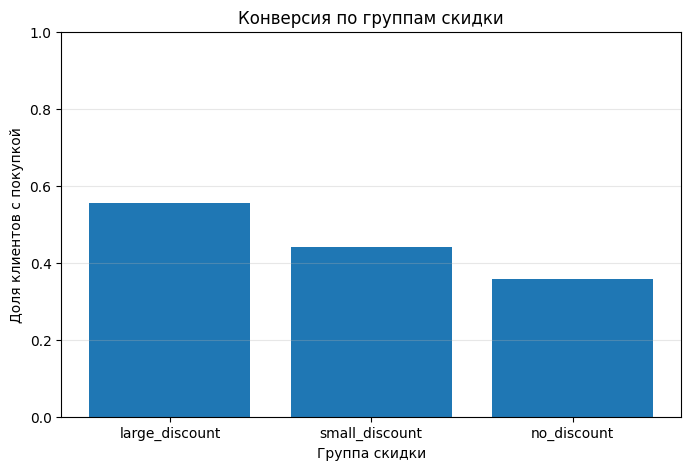

In [12]:
conversion_rate = df_clean.groupby('discount_group')['converted'].mean().sort_values(ascending=False)  # Считаем конверсию как среднее значение converted по группам скидки.

plt.figure(figsize=(8, 5))  # Создаём область графика размером 8 на 5 дюймов.
plt.bar(conversion_rate.index, conversion_rate.values)  # Строим столбчатую диаграмму конверсии по группам скидки.
plt.title('Конверсия по группам скидки')  # Добавляем заголовок графика.
plt.xlabel('Группа скидки')  # Подписываем ось X.
plt.ylabel('Доля клиентов с покупкой')  # Подписываем ось Y.
plt.ylim(0, 1)  # Ограничиваем шкалу Y диапазоном от 0 до 1, так как конверсия является долей.
plt.grid(axis='y', alpha=0.3)  # Добавляем горизонтальную сетку.
plt.show()  # Отображаем график.


## 15. Основы статистического тестирования

Перед тестом нужно выполнить четыре действия:

1. Сформулировать H0 и H1.
2. Выбрать уровень значимости, обычно `alpha = 0.05`.
3. Выбрать тест по типу переменных.
4. Интерпретировать результат аккуратно.

Типовая интерпретация:

- если `p-value < alpha`, отклоняем H0;
- если `p-value >= alpha`, нет достаточных оснований отклонить H0.

Нельзя писать: «H0 доказана». Корректнее: «по имеющимся данным нет достаточных оснований отклонить H0».

In [13]:
alpha = 0.05  # Задаём уровень значимости для статистических тестов.
print(f'Уровень значимости alpha = {alpha}')  # Выводим выбранный уровень значимости.


Уровень значимости alpha = 0.05


## 16. Тест 1. Есть ли статистически значимая связь между посещениями и заказами?

Формулировка:

- H0: статистически значимой корреляции между числом посещений и числом заказов нет;
- H1: статистически значимая корреляция между числом посещений и числом заказов есть.

Так как обе переменные числовые, можно использовать корреляционный тест. Для устойчивости применим Spearman.

In [14]:
spearman_stat, spearman_p = stats.spearmanr(df_clean['monthly_visits'], df_clean['orders_count'])  # Проверяем ранговую связь между посещениями и заказами.

print(f'Spearman correlation: {spearman_stat:.3f}')  # Выводим коэффициент корреляции Spearman.
print(f'p-value: {spearman_p:.6f}')  # Выводим p-value для проверки статистической значимости связи.

if spearman_p < alpha:  # Сравниваем p-value с уровнем значимости.
    print('Вывод: H0 отклоняется. Связь статистически значима.')  # Печатаем вывод, если связь статистически значима.
else:  # Обрабатываем ситуацию, когда p-value не меньше alpha.
    print('Вывод: нет достаточных оснований отклонить H0.')  # Печатаем осторожный вывод, если значимость не подтверждена.


Spearman correlation: 0.331
p-value: 0.000000
Вывод: H0 отклоняется. Связь статистически значима.


### Интерпретация теста 1

Если связь статистически значима, это означает, что в данных наблюдается неслучайная ассоциация между посещениями и заказами. Но даже в этом случае нельзя автоматически писать, что посещения являются причиной заказов. Возможны дополнительные факторы: качество клиента, источник трафика, промоакции, сезонность, товарная категория.

## 17. Тест 2. Отличается ли средний чек у клиентов из двух каналов?

Сравним `organic` и `ads`.

Формулировка:

- H0: средний чек клиентов из `organic` и `ads` не различается;
- H1: средний чек клиентов из `organic` и `ads` различается.

Так как сравниваются две независимые группы и числовой показатель, можно использовать t-test. Но сначала полезно посмотреть размеры групп и распределения.

In [15]:
organic_basket = df_clean.loc[df_clean['traffic_source'] == 'organic', 'basket_value']  # Отбираем средний чек клиентов из organic-канала.
ads_basket = df_clean.loc[df_clean['traffic_source'] == 'ads', 'basket_value']  # Отбираем средний чек клиентов из ads-канала.

print('Размер группы organic:', len(organic_basket))  # Выводим число наблюдений в группе organic.
print('Размер группы ads:', len(ads_basket))  # Выводим число наблюдений в группе ads.
print('Медиана organic:', round(organic_basket.median(), 2))  # Выводим медианный средний чек для organic.
print('Медиана ads:', round(ads_basket.median(), 2))  # Выводим медианный средний чек для ads.


Размер группы organic: 318
Размер группы ads: 289
Медиана organic: 5515.5
Медиана ads: 5007.0


In [16]:
t_stat, t_p = stats.ttest_ind(organic_basket, ads_basket, equal_var=False)  # Выполняем t-test Welch для сравнения средних двух независимых групп.

print(f't-statistic: {t_stat:.3f}')  # Выводим значение t-статистики.
print(f'p-value: {t_p:.6f}')  # Выводим p-value теста.

if t_p < alpha:  # Сравниваем p-value с уровнем значимости.
    print('Вывод: H0 отклоняется. Средний чек статистически значимо различается между группами.')  # Печатаем вывод при статистически значимом различии.
else:  # Обрабатываем ситуацию, когда p-value не меньше alpha.
    print('Вывод: нет достаточных оснований считать средний чек различающимся.')  # Печатаем осторожный вывод при отсутствии статистической значимости.


t-statistic: 6.654
p-value: 0.000000
Вывод: H0 отклоняется. Средний чек статистически значимо различается между группами.


### Размер эффекта: Cohen's d

Статистическая значимость не показывает, насколько различие велико practically. На большом датасете даже маленькая разница может стать статистически значимой. Поэтому полезно считать размер эффекта.

Для двух групп часто используют Cohen's d.

In [17]:
def cohens_d(x, y):  # Создаём функцию для расчёта размера эффекта Cohen's d.
    x = pd.Series(x).dropna()  # Преобразуем первую выборку в Series и удаляем пропуски.
    y = pd.Series(y).dropna()  # Преобразуем вторую выборку в Series и удаляем пропуски.
    nx = len(x)  # Считаем размер первой выборки.
    ny = len(y)  # Считаем размер второй выборки.
    pooled_std = np.sqrt(((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / (nx + ny - 2))  # Рассчитываем объединённое стандартное отклонение.
    return (x.mean() - y.mean()) / pooled_std  # Возвращаем размер эффекта как разницу средних в единицах стандартного отклонения.

basket_d = cohens_d(organic_basket, ads_basket)  # Рассчитываем Cohen's d для organic и ads.
print(f"Cohen's d: {basket_d:.3f}")  # Выводим размер эффекта с округлением до трёх знаков.


Cohen's d: 0.539


## 18. Тест 3. Отличается ли средний чек между несколькими каналами?

Если групп больше двух, t-test применять многократно без контроля ошибок некорректно. Для сравнения нескольких групп можно использовать ANOVA.

Формулировка:

- H0: средний чек не различается между каналами привлечения;
- H1: хотя бы в одной группе средний чек отличается.

ANOVA показывает наличие различий в целом, но не говорит, между какими именно группами есть различие. Для точного попарного сравнения нужны дополнительные post-hoc тесты, но в базовом notebook ограничимся общей проверкой.

In [18]:
source_groups = [  # Создаём список выборок среднего чека для каждого канала привлечения.
    group['basket_value'].values  # Берём значения среднего чека внутри одной группы.
    for _, group in df_clean.groupby('traffic_source')  # Повторяем операцию для каждой группы traffic_source.
]  # Завершаем создание списка выборок для ANOVA.

f_stat, anova_p = stats.f_oneway(*source_groups)  # Выполняем однофакторный ANOVA-тест для сравнения средних между несколькими группами.

print(f'ANOVA F-statistic: {f_stat:.3f}')  # Выводим F-статистику ANOVA.
print(f'p-value: {anova_p:.6f}')  # Выводим p-value ANOVA.

if anova_p < alpha:  # Сравниваем p-value с уровнем значимости.
    print('Вывод: H0 отклоняется. Есть статистически значимые различия между каналами.')  # Печатаем вывод при значимых различиях.
else:  # Обрабатываем ситуацию, когда p-value не меньше alpha.
    print('Вывод: нет достаточных оснований считать средний чек различающимся между каналами.')  # Печатаем осторожный вывод при отсутствии значимости.


ANOVA F-statistic: 59.201
p-value: 0.000000
Вывод: H0 отклоняется. Есть статистически значимые различия между каналами.


### Размер эффекта для ANOVA: eta squared

Для ANOVA полезно оценить долю вариации числового показателя, связанную с группировкой. Простая мера — eta squared.

In [19]:
def eta_squared(data, group_col, value_col):  # Создаём функцию для расчёта eta squared как размера эффекта для ANOVA.
    overall_mean = data[value_col].mean()  # Считаем общее среднее значение анализируемого показателя.
    ss_between = sum(  # Начинаем расчёт межгрупповой суммы квадратов.
        len(group) * (group[value_col].mean() - overall_mean) ** 2  # Считаем вклад каждой группы в межгрупповую вариацию.
        for _, group in data.groupby(group_col)  # Повторяем расчёт для каждой группы.
    )  # Завершаем расчёт межгрупповой суммы квадратов.
    ss_total = ((data[value_col] - overall_mean) ** 2).sum()  # Считаем общую сумму квадратов отклонений от общего среднего.
    return ss_between / ss_total  # Возвращаем долю общей вариации, объяснённую группировкой.

eta2 = eta_squared(df_clean, 'traffic_source', 'basket_value')  # Рассчитываем eta squared для связи канала привлечения и среднего чека.
print(f'Eta squared: {eta2:.3f}')  # Выводим размер эффекта с округлением до трёх знаков.


Eta squared: 0.165


## 19. Тест 4. Есть ли связь между скидкой и фактом покупки?

Для двух категориальных переменных используется chi-square test.

Формулировка:

- H0: группа скидки и факт покупки независимы;
- H1: группа скидки и факт покупки связаны.

In [20]:
contingency = pd.crosstab(df_clean['discount_group'], df_clean['converted'])  # Создаём таблицу сопряжённости скидочной группы и факта покупки.
chi2, chi2_p, dof, expected = stats.chi2_contingency(contingency)  # Выполняем chi-square тест независимости для категориальных переменных.

print('Таблица сопряжённости:')  # Печатаем заголовок таблицы сопряжённости.
display(contingency)  # Показываем таблицу фактических частот.

print(f'Chi-square statistic: {chi2:.3f}')  # Выводим значение chi-square статистики.
print(f'p-value: {chi2_p:.6f}')  # Выводим p-value теста.
print(f'Degrees of freedom: {dof}')  # Выводим число степеней свободы.

if chi2_p < alpha:  # Сравниваем p-value с уровнем значимости.
    print('Вывод: H0 отклоняется. Между скидкой и фактом покупки есть статистически значимая связь.')  # Печатаем вывод при наличии значимой связи.
else:  # Обрабатываем ситуацию, когда p-value не меньше alpha.
    print('Вывод: нет достаточных оснований считать переменные связанными.')  # Печатаем осторожный вывод при отсутствии статистической значимости.


Таблица сопряжённости:


converted,0,1
discount_group,,
large_discount,78,97
no_discount,242,135
small_discount,195,153


Chi-square statistic: 19.122
p-value: 0.000070
Degrees of freedom: 2
Вывод: H0 отклоняется. Между скидкой и фактом покупки есть статистически значимая связь.


### Размер эффекта для категориальных переменных: Cramer's V

Chi-square показывает статистическую значимость связи. Cramer's V помогает оценить силу связи.

Значение Cramer's V находится от 0 до 1:

- ближе к 0 — слабая связь;
- ближе к 1 — сильная связь.

In [21]:
def cramers_v(confusion_matrix):  # Создаём функцию для расчёта Cramer's V как размера эффекта для таблицы сопряжённости.
    chi2 = stats.chi2_contingency(confusion_matrix)[0]  # Получаем chi-square статистику для таблицы сопряжённости.
    n = confusion_matrix.to_numpy().sum()  # Считаем общее количество наблюдений в таблице.
    r, k = confusion_matrix.shape  # Получаем число строк и столбцов в таблице.
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))  # Возвращаем Cramer's V с поправкой на размер таблицы.

cv = cramers_v(contingency)  # Рассчитываем Cramer's V для связи скидки и факта покупки.
print(f"Cramer's V: {cv:.3f}")  # Выводим размер эффекта с округлением до трёх знаков.


Cramer's V: 0.146


## 20. Непараметрическая альтернатива: Mann-Whitney U

Если распределения сильно асимметричны или есть выбросы, вместо t-test можно использовать Mann-Whitney U test. Он сравнивает не средние значения напрямую, а распределения / ранги двух независимых групп.

Применим его к тем же группам `organic` и `ads`.

In [22]:
u_stat, u_p = stats.mannwhitneyu(organic_basket, ads_basket, alternative='two-sided')  # Выполняем непараметрический тест Mann-Whitney для двух независимых групп.

print(f'Mann-Whitney U statistic: {u_stat:.3f}')  # Выводим U-статистику теста.
print(f'p-value: {u_p:.6f}')  # Выводим p-value теста.

if u_p < alpha:  # Сравниваем p-value с уровнем значимости.
    print('Вывод: H0 отклоняется. Распределения двух групп статистически значимо различаются.')  # Печатаем вывод при значимом различии распределений.
else:  # Обрабатываем ситуацию, когда p-value не меньше alpha.
    print('Вывод: нет достаточных оснований считать распределения двух групп различающимися.')  # Печатаем осторожный вывод при отсутствии значимости.


Mann-Whitney U statistic: 59725.000
p-value: 0.000000
Вывод: H0 отклоняется. Распределения двух групп статистически значимо различаются.


## 21. Как оформлять результат теста

Для каждого теста удобно использовать единый шаблон:

1. Аналитический вопрос.
2. H0 и H1.
3. Использованный тест.
4. Уровень значимости.
5. Основные числовые результаты.
6. Размер эффекта, если применимо.
7. Вывод простым языком.
8. Ограничения интерпретации.

Такой формат снижает риск написать вывод, который не следует из данных.

## 22. Пример аккуратного вывода по тесту

Пример формулировки:

> В данных обнаружена статистически значимая связь между группой скидки и фактом покупки: `p-value < 0.05`. Конверсия выше в группах со скидкой, однако этот результат нельзя интерпретировать как доказательство того, что скидка сама по себе является причиной покупки. Для причинного вывода нужно учитывать дизайн эксперимента, случайное распределение клиентов, сезонность, канал привлечения и другие факторы.

Такой вывод корректнее, чем фраза «скидка увеличивает покупки», потому что текущие данные показывают связь, а не обязательно причинное воздействие.

## 23. Итоговый дашборд

В конце анализа полезно собрать несколько ключевых графиков на одной странице. Это помогает увидеть общую картину и подготовить компактный вывод.

В нашем случае дашборд будет включать:

1. конверсию по группам скидки;
2. медианный чек по каналам;
3. scatter plot посещений и заказов;
4. распределение среднего чека;
5. краткую таблицу ключевых метрик.

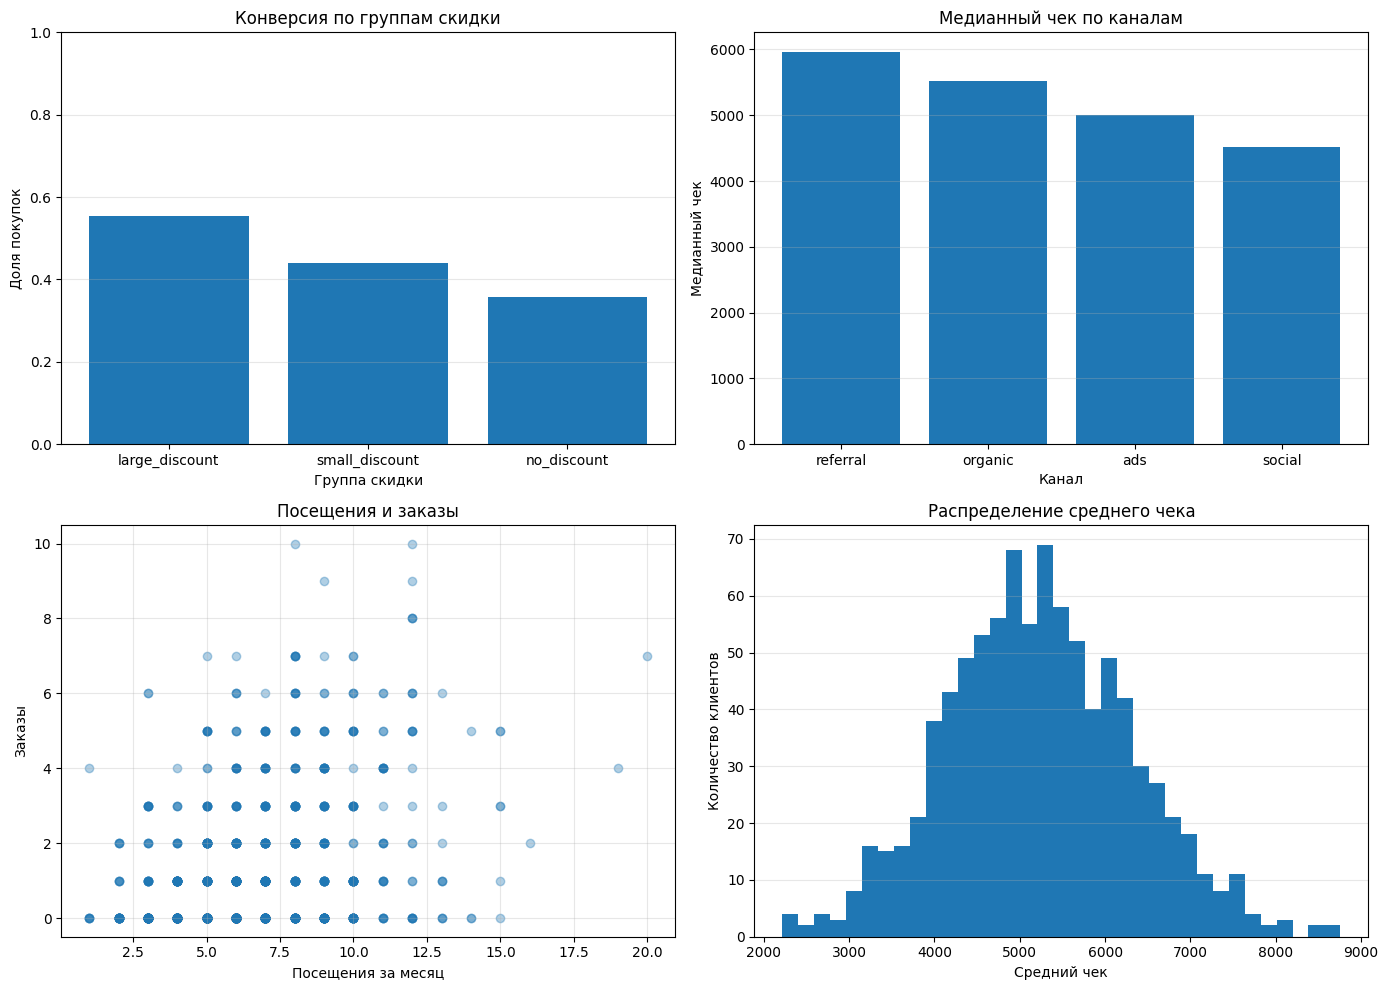

,metric,value
0,Количество клиентов,900.000
1,"Средний чек, медиана",5204.000
2,"Средний чек, среднее",5227.040
3,Общая конверсия,0.428
4,Среднее число посещений,6.670
5,Среднее число заказов,1.400


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # Создаём сетку из четырёх графиков: 2 строки и 2 столбца.

conversion_rate = df_clean.groupby('discount_group')['converted'].mean().sort_values(ascending=False)  # Считаем конверсию по группам скидки для первого графика.
axes[0, 0].bar(conversion_rate.index, conversion_rate.values)  # Строим столбчатый график конверсии по группам скидки.
axes[0, 0].set_title('Конверсия по группам скидки')  # Задаём заголовок первого графика.
axes[0, 0].set_xlabel('Группа скидки')  # Подписываем ось X первого графика.
axes[0, 0].set_ylabel('Доля покупок')  # Подписываем ось Y первого графика.
axes[0, 0].set_ylim(0, 1)  # Ограничиваем шкалу Y от 0 до 1, так как конверсия является долей.
axes[0, 0].grid(axis='y', alpha=0.3)  # Добавляем горизонтальную сетку на первый график.

basket_by_source = df_clean.groupby('traffic_source')['basket_value'].median().sort_values(ascending=False)  # Считаем медианный средний чек по каналам для второго графика.
axes[0, 1].bar(basket_by_source.index, basket_by_source.values)  # Строим столбчатый график медианного чека по каналам.
axes[0, 1].set_title('Медианный чек по каналам')  # Задаём заголовок второго графика.
axes[0, 1].set_xlabel('Канал')  # Подписываем ось X второго графика.
axes[0, 1].set_ylabel('Медианный чек')  # Подписываем ось Y второго графика.
axes[0, 1].grid(axis='y', alpha=0.3)  # Добавляем горизонтальную сетку на второй график.

axes[1, 0].scatter(df_clean['monthly_visits'], df_clean['orders_count'], alpha=0.35)  # Строим диаграмму рассеяния посещений и заказов.
axes[1, 0].set_title('Посещения и заказы')  # Задаём заголовок третьего графика.
axes[1, 0].set_xlabel('Посещения за месяц')  # Подписываем ось X третьего графика.
axes[1, 0].set_ylabel('Заказы')  # Подписываем ось Y третьего графика.
axes[1, 0].grid(True, alpha=0.3)  # Добавляем сетку на третий график.

axes[1, 1].hist(df_clean['basket_value'], bins=35)  # Строим гистограмму распределения среднего чека.
axes[1, 1].set_title('Распределение среднего чека')  # Задаём заголовок четвёртого графика.
axes[1, 1].set_xlabel('Средний чек')  # Подписываем ось X четвёртого графика.
axes[1, 1].set_ylabel('Количество клиентов')  # Подписываем ось Y четвёртого графика.
axes[1, 1].grid(axis='y', alpha=0.3)  # Добавляем горизонтальную сетку на четвёртый график.

plt.tight_layout()  # Уплотняем размещение графиков, чтобы подписи и заголовки не пересекались.
plt.show()  # Отображаем итоговый дашборд из четырёх графиков.

summary = pd.DataFrame({  # Создаём итоговую таблицу ключевых метрик.
    'metric': [  # Задаём названия метрик, которые будут показаны в итоговой таблице.
        'Количество клиентов',  # Добавляем метрику количества клиентов.
        'Средний чек, медиана',  # Добавляем метрику медианного среднего чека.
        'Средний чек, среднее',  # Добавляем метрику среднего значения среднего чека.
        'Общая конверсия',  # Добавляем метрику общей конверсии.
        'Среднее число посещений',  # Добавляем метрику среднего числа посещений.
        'Среднее число заказов'  # Добавляем метрику среднего числа заказов.
    ],  # Завершаем список названий метрик.
    'value': [  # Задаём значения метрик в том же порядке.
        len(df_clean),  # Считаем количество клиентов после очистки.
        round(df_clean['basket_value'].median(), 2),  # Считаем медиану среднего чека и округляем.
        round(df_clean['basket_value'].mean(), 2),  # Считаем средний средний чек и округляем.
        round(df_clean['converted'].mean(), 3),  # Считаем общую конверсию и округляем.
        round(df_clean['monthly_visits'].mean(), 2),  # Считаем среднее число посещений и округляем.
        round(df_clean['orders_count'].mean(), 2)  # Считаем среднее число заказов и округляем.
    ]  # Завершаем список значений метрик.
})  # Завершаем создание итоговой таблицы.

display(summary)  # Показываем итоговую таблицу ключевых метрик.


## 24. Итоговая интерпретация по примеру

По демонстрационным данным можно сформулировать несколько осторожных выводов:

1. Между числом посещений и числом заказов наблюдается положительная связь. Это логично: более активные клиенты чаще совершают заказы. Однако причинность из этого анализа не следует.
2. Средний чек различается между каналами привлечения. Это может быть связано с разным качеством трафика, разными сегментами клиентов или особенностями маркетинговых кампаний.
3. Между группой скидки и фактом покупки есть статистически значимая связь. Но для доказательства причинного эффекта скидки нужен экспериментальный дизайн или дополнительный контроль факторов.
4. Статистическая значимость должна дополняться размером эффекта. Если эффект мал, результат может быть формально значимым, но слабым с практической точки зрения.

## 25. Ограничения анализа

Любой анализ должен завершаться указанием ограничений. В нашем примере ограничения такие:

- данные синтетические, поэтому выводы демонстрируют метод, а не реальный бизнес-результат;
- не учитываются сезонность, товарные категории, повторные покупки и стоимость привлечения;
- связь между показателями не доказывает причинность;
- статистические тесты чувствительны к размеру выборки, выбросам и распределению данных;
- для строгих причинных выводов нужен эксперимент, например A/B-тест, или более сложная модель с контролем факторов.

## 26. Чек-лист качества аналитической работы

Перед сдачей или публикацией анализа проверьте:

- сформулирована ли аналитическая цель;
- описаны ли поля таблицы;
- проверены ли пропуски, дубликаты и некорректные значения;
- объяснено ли, как обрабатывались пропуски;
- правильно ли выбран метод анализа под типы переменных;
- есть ли графики с заголовками и подписями осей;
- различаются ли факт, интерпретация и гипотеза;
- не сделаны ли причинные выводы там, где есть только связь;
- указан ли размер эффекта, если он уместен;
- зафиксированы ли ограничения анализа;
- запускается ли notebook сверху вниз без ошибок.

## 27. Краткая шпаргалка: какой тест выбрать

| Задача | Тип данных | Метод |
|---|---|---|
| Связь двух числовых переменных | числовая ↔ числовая | Pearson или Spearman |
| Сравнить среднее в двух независимых группах | категориальная с 2 группами ↔ числовая | t-test или Mann-Whitney |
| Сравнить среднее в нескольких группах | категориальная с 3+ группами ↔ числовая | ANOVA или Kruskal-Wallis |
| Проверить связь двух категориальных переменных | категориальная ↔ категориальная | Chi-square test |
| Оценить силу связи категориальных переменных | категориальная ↔ категориальная | Cramer's V |
| Оценить практическую величину различия двух групп | 2 группы ↔ числовая | Cohen's d |

Главное правило: сначала определить тип переменных и аналитический вопрос, затем выбирать метод.

## 28. Финальный вывод

Анализ взаимосвязей и тестирование гипотез — это не набор отдельных команд, а последовательный процесс. Сначала нужно понять данные и их качество, затем выбрать корректный метод сравнения, после этого выполнить расчёты и только потом формулировать вывод.

Хороший вывод должен быть аккуратным:

- он опирается на реальные расчёты;
- не преувеличивает статистическую значимость;
- не подменяет связь причинностью;
- указывает ограничения;
- предлагает следующий практический шаг.

Если соблюдать эту последовательность, notebook становится не просто набором графиков, а полноценным аналитическим документом.